# Optional Lab: 多元变量线性回归

在这个实验室中，你将扩展数据结构和先前开发的例程以支持多个特征。一些例程被更新，使得实验室看起来很长，但它对先前的例程进行了微小的调整，使得审查起来很快。
# 大纲
- [&nbsp;&nbsp;1.1 目标](#toc_15456_1.1)
- [&nbsp;&nbsp;1.2 工具](#toc_15456_1.2)
- [&nbsp;&nbsp;1.3 符号说明](#toc_15456_1.3)
- [2 问题陈述](#toc_15456_2)
- [&nbsp;&nbsp;2.1 包含我们示例的矩阵 X](#toc_15456_2.1)
- [&nbsp;&nbsp;2.2 参数向量 w 和 b。](#toc_15456_2.2)
- [3 多变量模型预测](#toc_15456_3)
- [&nbsp;&nbsp;3.1 逐个元素的单一预测](#toc_15456_3.1)
- [&nbsp;&nbsp;3.2 单变量预测，向量](#toc_15456_3.2)
- [4 使用多个变量计算成本](#toc_15456_4)
- [5 多变量梯度下降法](#toc_15456_5)
- [&nbsp;&nbsp;5.1 多变量计算梯度](#toc_15456_5.1)
- [&nbsp;&nbsp;5.2 多变量梯度下降法](#toc_15456_5.2)
- [6 恭喜！](#toc_15456_6)


<a name="toc_15456_1.1"></a>
## 1.1 目标
- 扩展我们的回归模型例程以支持多个特征
    - 扩展数据结构以支持多个特征
    - 重写预测、成本和梯度例程以支持多个特征
    - 利用 NumPy 的`np.dot`将其实现向量化以提高速度和简洁性

<a name="toc_15456_1.2"></a>
## 1.2 工具
在本实验中，我们将使用：
- NumPy，一个流行的科学计算库。
- Matplotlib，一个流行的绘图数据库。

In [1]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays

<a name="toc_15456_1.3"></a>
## 1.3 符号
以下是一些你将遇到的符号总结，已针对多个特征进行了更新。
|通用符号|描述|Python（如果适用）|
|:------------|:------------------------------------------------------------|---|
|$a$|标量，非粗体||
|$\mathbf{a}$|向量，粗体||
|$\mathbf{A}$|矩阵，粗体大写||
|**回归**|         |    |     |
|$\mathbf{X}$|训练样本矩阵|`X_train`|
|$\mathbf{y}$|训练样本目标|`y_train`|
|$\mathbf{x}^{(i)}$，$y^{(i)}$|第$i$个训练样本|`X[i]`，`y[i]`|
|$m$|训练样本数量|`m`|
|$n$|每个样本的特征数量|`n`|
|$\mathbf{w}$|参数：权重|`w`|
|$b$|参数：偏差|`b`|
|$f_{\mathbf{w},b}(\mathbf{x}^{(i)})$|在由$\mathbf{w}$，$b$参数化的$\mathbf{x^{(i)}}$处的模型评估结果：$f_{\mathbf{w},b}(\mathbf{x}^{(i)})=\mathbf{w}\cdot\mathbf{x}^{(i)}+b$|`f_wb`|


<a name="toc_15456_2"></a>
# 2 问题陈述

你将使用房价预测这个激励性的例子。训练数据集包含三个示例，具有四个特征（面积、卧室数量、楼层数和房屋年龄），如下表所示。请注意，与之前的实验不同，面积的单位是平方英尺而不是 1000 平方英尺。这会导致一个问题，你将在下一个实验中解决这个问题！

|面积（平方英尺）|卧室数量|楼层数|房屋年龄|价格（千美元）|
|----|----|----|----|----|
|2104|5|1|45|460|
|1416|3|2|40|232|
|852|2|1|35|178|

你将使用这些值构建一个线性回归模型，以便能够预测其他房屋的价格。例如，一个面积为 1200 平方英尺、有 3 间卧室、1 层楼、40 年房龄的房子。

请运行以下代码单元以创建你的`X_train`和`y_train`变量。

In [2]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

<a name="toc_15456_2.1"></a>
## 2.1 包含我们示例的矩阵 X
与上述表格类似，示例存储在 NumPy 矩阵`X_train`中。矩阵的每一行代表一个示例。当你有$m$个训练示例（在我们的例子中$m$是三），并且有$n$个特征（在我们的例子中是四个）时，$\mathbf{X}$是一个维度为（$m$，$n$）的矩阵（$m$行，$n$列）。  

$$\mathbf{X} = 
\begin{pmatrix}
 x^{(0)}_0 & x^{(0)}_1 & \cdots & x^{(0)}_{n - 1}\\ 
 x^{(1)}_0 & x^{(1)}_1 & \cdots & x^{(1)}_{n - 1}\\
 \cdots \\
 x^{(m - 1)}_0 & x^{(m - 1)}_1 & \cdots & x^{(m - 1)}_{n - 1} 
\end{pmatrix}
$$


符号说明：
- $\mathbf{x}^{(i)}$是包含示例$i$的向量。 $\mathbf{x}^{(i)} = (x^{(i)}_0, x^{(i)}_1, \cdots,x^{(i)}_{n - 1})$ 。
- $x^{(i)}_j$是示例$i$中的元素$j$。括号中的上标表示示例编号，而下标表示一个元素。
显示输入数据。

## 2.2 参数向量 w，b

In [3]:
# 数据存储在 numpy 数组/矩阵中。
print(f"X Shape: {X_train.shape}, X Type:{type(X_train)})")
print(X_train)
print(f"y Shape: {y_train.shape}, y Type:{type(y_train)})")
print(y_train)

X Shape: (3, 4), X Type:<class 'numpy.ndarray'>)
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y Shape: (3,), y Type:<class 'numpy.ndarray'>)
[460 232 178]


<a name="toc_15456_2.2"></a>
## 2.2 参数向量 w，b
* $\mathbf{w}$是一个具有$n$个元素的向量。
    - 每个元素包含与一个特征相关联的参数。
    - 在我们的数据集中，$n$是 4。
    - 概念上，我们将其绘制成一个列向量
$$\mathbf{w} = \begin{pmatrix}
w_0 \\ 
w_1 \\
\cdots\\
w_{n - 1}
\end{pmatrix}
$$
* $b$是一个标量参数。

为了进行演示，$\mathbf{w}$和$b$将被加载一些接近最优值的初始选定值。$\mathbf{w}$是一个一维 NumPy 向量。

In [4]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


<a name="toc_15456_3"></a>
# 3 多变量的模型预测
多变量的模型预测由线性模型给出：
$$ f_{\mathbf{w},b}(\mathbf{x}) =  w_0x_0 + w_1x_1 +... + w_{n - 1}x_{n - 1} + b \tag{1}$$
或者用向量表示法：
$$ f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b  \tag{2} $$
其中$\cdot$是向量“点积”。
为了演示点积，我们将使用（1）和（2）实现预测。

<a name="toc_15456_3.1"></a>
## 3.1 逐个元素的单次预测
我们之前的预测是将一个特征值与一个参数相乘，然后加上一个偏差参数。将我们之前的预测实现直接扩展到多个特征，就是使用对每个元素的循环来实现上述（1），用其参数进行乘法运算，然后在最后加上偏差参数。


In [5]:
def predict_single_loop(x, w, b): 
    """
    single predict using linear regression
    
    Args:
      x (ndarray): Shape (n,) example with multiple features
      w (ndarray): Shape (n,) model parameters    
      b (scalar):  model parameter     
      
    Returns:
      p (scalar):  prediction
    """
    n = x.shape[0]
    p = 0
    for i in range(n):
        p_i = x[i] * w[i]  
        p = p + p_i         
    p = p + b                
    return p

In [6]:
# 从我们的训练数据中获取一行。
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# 进行预测
f_wb = predict_single_loop(x_vec, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


注意`x_vec`的形状。它是一个具有 4 个元素的一维 NumPy 向量(4,)。结果`f_wb`是一个标量。

<a name="toc_15456_3.2"></a>
## 3.2 单次预测，向量
注意，上面的方程(1)可以使用上面方程(2)中的点积来实现。我们可以利用向量运算来加速预测。
回想一下在 Python/Numpy 实验室中，NumPy 的`np.dot()`[[链接](https://numpy.org/doc/stable/reference/generated/numpy.dot.html)]可以用于执行向量点积。

In [7]:
def predict(x, w, b): 
    """
    single predict using linear regression
    Args:
      x (ndarray): Shape (n,) example with multiple features
      w (ndarray): Shape (n,) model parameters   
      b (scalar):             model parameter 
      
    Returns:
      p (scalar):  prediction
    """
    p = np.dot(x, w) + b     
    return p    

In [8]:
# 从我们的训练数据中获取一行。
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# 做出预测
f_wb = predict(x_vec,w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


结果和形状与使用循环的上一个版本相同。今后，`np.dot`将用于这些操作。现在预测是一个单一的语句。大多数例程将直接实现它，而不是调用单独的预测例程。

<a name="toc_15456_4"></a>
# 4 计算多变量成本
多变量成本函数$J(\mathbf{w},b)$的方程为：
$$J(\mathbf{w},b)=\frac{1}{2m}\sum\limits_{i = 0}^{m - 1}(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2\tag{3}$$
其中：
$$f_{\mathbf{w},b}(\mathbf{x}^{(i)})=\mathbf{w}\cdot\mathbf{x}^{(i)} + b\tag{4}$$
与之前的实验不同，$\mathbf{w}$和$\mathbf{x}^{(i)}$是向量而不是支持多个特征的标量。

以下是方程（3）和（4）的实现。请注意，这里使用了本课程的*标准模式*，即使用一个针对所有`m`个样本的 for 循环。

In [9]:
def compute_cost(X, y, w, b): 
    """
    compute cost
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):                                
        f_wb_i = np.dot(X[i], w) + b           #(n,)(n,) = scalar (see np.dot)
        cost = cost + (f_wb_i - y[i])**2       #scalar
    cost = cost / (2 * m)                      #scalar    
    return cost

In [10]:
# Compute and display cost using our pre-chosen optimal parameters. 
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 1.5578904045996674e-12


**预期结果**：最优 w 的成本：1.5578904045996674e-12

<a name="toc_15456_5"></a>
# 5 多变量梯度下降

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{5}  \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

其中，n 是特征的数量，参数$w_j$和$b$同时更新，并且其中:

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{6}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{7}
\end{align}
$$

* m 是数据集中训练样本的数量。

    
* $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$是模型的预测值，而$y^{(i)}$是目标值。


<a name="toc_15456_5.1"></a>
## 5.1 多变量计算梯度
以下是计算方程（6）和（7）的实现。有很多方法可以实现这一点。在这个版本中，有一个对所有m个样本的外层循环。
- 可以直接计算样本的$\frac{\partial J(\mathbf{w},b)}{\partial b}$并累积。
- 在对所有n个特征的第二层循环中：
  - 为每个$w_j$计算$\frac{\partial J(\mathbf{w},b)}{\partial w_j}$。
   

In [11]:
def compute_gradient(X, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar):       The gradient of the cost w.r.t. the parameter b. 
    """
    m,n = X.shape           #(number of examples, number of features)
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):                             
        err = (np.dot(X[i], w) + b) - y[i]   
        for j in range(n):                         
            dj_dw[j] = dj_dw[j] + err * X[i, j]    
        dj_db = dj_db + err                        
    dj_dw = dj_dw / m                                
    dj_db = dj_db / m                                
        
    return dj_db, dj_dw

In [12]:
#Compute and display gradient 
tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: -1.6739251122999121e-06
dj_dw at initial w,b: 
 [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]


**预期结果t**:   
dj_db at initial w,b: -1.6739251122999121e-06  
dj_dw at initial w,b:   
 [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]  

<a name="toc_15456_5.2"></a>
## 5.2 多元变量的梯度下降
下面的例程实现了上述公式（5）。

In [13]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X (ndarray (m,n))   : Data, m examples with n features
      y (ndarray (m,))    : target values
      w_in (ndarray (n,)) : initial model parameters  
      b_in (scalar)       : initial model parameter
      cost_function       : function to compute cost
      gradient_function   : function to compute the gradient
      alpha (float)       : Learning rate
      num_iters (int)     : number of iterations to run gradient descent
      
    Returns:
      w (ndarray (n,)) : Updated values of parameters 
      b (scalar)       : Updated value of parameter 
      """
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db,dj_dw = gradient_function(X, y, w, b)   ##None

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               ##None
        b = b - alpha * dj_db               ##None
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(X, y, w, b))

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")
        
    return w, b, J_history #return final w,b and J history for graphing

在下一个单元格中，你将测试这个实现。

In [16]:
# 初始化参数
initial_w = np.zeros_like(w_init)
initial_b = 0.
# 一些梯度下降设置
iterations = 100000
alpha = 5.0e-7
# 运行梯度下降算法
w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost  2529.46   
Iteration 10000: Cost   624.82   
Iteration 20000: Cost   594.33   
Iteration 30000: Cost   581.01   
Iteration 40000: Cost   574.73   
Iteration 50000: Cost   571.36   
Iteration 60000: Cost   569.18   
Iteration 70000: Cost   567.49   
Iteration 80000: Cost   566.01   
Iteration 90000: Cost   564.61   
b,w found by gradient descent: -0.04,[ 0.24  0.29 -0.86 -1.58] 
prediction: 439.29, target value: 460
prediction: 279.08, target value: 232
prediction: 150.90, target value: 178


**预期结果**:    
通过梯度下降找到的 b,w：-0.00,[0.2 0. -0.01 -0.07]  
预测值：426.19，目标值：460  
预测值：286.17，目标值：232  
预测值：171.47，目标值：178

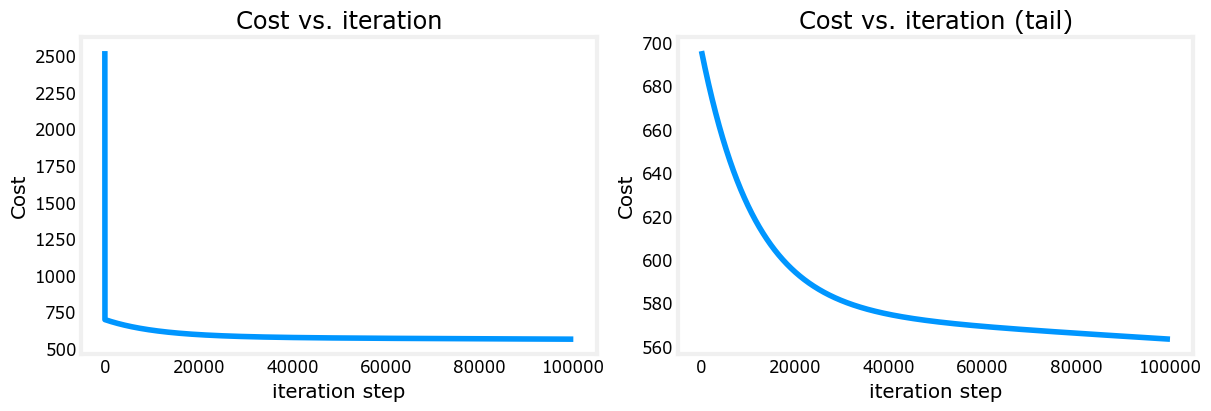

In [17]:
# 绘制成本与迭代次数的关系图。 
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

*这些结果并不鼓舞人心。* 成本仍在下降，并且我们的预测不是很准确。下一个实验将探索如何改进这一点。


<a name="toc_15456_6"></a>
# 6 恭喜！
在本实验中，你：
- 重新开发了线性回归的例程，现在可以处理多个变量。
- 使用 NumPy 的`np.dot`对实现进行向量化。